---
title: "Modelling protein detectability with an MLP"

date: 2022-09-21

# date-modified: last-modified

author:

- name: Eric Deutsch

  orcid: 0000-0001-8732-0928

  affiliations:
    - Institute for Systems Biology, Seattle WA, USA

---

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ProteomicsML/ProteomicsML/blob/main/tutorials/detectability/_modeling-protein-detectability.ipynb)


# Introduction

When subjecting whole cell lysates to mass spectrometry-based proteomics analysis, some proteins are easily detected while others are not seen. The proteins that are never detected are often colloquially called the dark proteome. There are many reasons for not detecting proteins. Some proteins may only be found in certain cell types or in certain developmental stages. Comprehensive accumulation of datasets from different cell types and developmental stages can overcome this limitation. Other reasons such as the physicochemical properties of the proteins may hinder detection. Here we explore the "light and dark proteome" based on proteins that are observed and not observed in the Arabidopsis PeptideAtlas, which has been assembled by search over 200 million MS/MS spectra from 100 different datasets. 

First we import some needed libraries

In [ ]:
# ! pip install numpy~=1.21 pandas~=1.3 matplotlib~=3.5 scikit-learn~=1.0 --quiet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

Read input data and extract the columns to train on. We will attempt to train on the protein molecular weight, protein physicochemical properties gravy score (a measure of hydrophobicity), isoelectric point (pI), and then two metrics from RNA-seq analysis: the percentage of RNA-seq experiments that detect a transcript for the given protein, and the highest TPM (transcripts per million, i.e. abundance) in any one dataset.

In [11]:
proteins = pd.read_csv('http://www.peptideatlas.org/builds/arabidopsis/light_and_dark_protein_list.tsv', sep="\t")
learning_values = proteins[ ['molecular_weight', 'gravy', 'pI', 'rna_detected_percent', 'highest_tpm' ] ].copy()

Normalize the data to have ranges like 0 to 1

In [12]:
learning_values['molecular_weight'] = pd.to_numeric(
    learning_values['molecular_weight'], errors='coerce'
)

In [13]:
learning_values.loc[ :, 'molecular_weight'] = learning_values['molecular_weight'] / 100
learning_values.loc[ learning_values[ 'molecular_weight'] > 1, 'molecular_weight'] = 1.0
learning_values.loc[ :, 'gravy'] = ( learning_values['gravy'] + 2 ) / 4
learning_values.loc[ :, 'pI'] = ( learning_values['pI'] - 4 ) / 8

learning_values.loc[ :, 'rna_detected_percent'] = learning_values['rna_detected_percent'] / 100
learning_values.loc[ :, 'highest_tpm'] = learning_values['highest_tpm'] / 300
learning_values.loc[ learning_values[ 'highest_tpm'] > 1, 'highest_tpm'] = 1.0

In [14]:
print(learning_values['molecular_weight'].dtype)
print(learning_values['molecular_weight'].head())

float64
0    0.494252
1    0.402870
2    1.000000
3    0.244838
4    0.704372
Name: molecular_weight, dtype: float64


Set the classifications to 0 and 1

In [15]:
classes = proteins['status'].map({'canonical': 1, 'not observed': 0})

# Check for any status values that didn't match either label
unmatched = proteins.loc[classes.isna(), 'status'].unique()
if len(unmatched) > 0:
    print("Warning: unmapped status values found:", unmatched)

if classes.isna().sum() == 0:
    classes = classes.astype(int)

In [ ]:
# classes = proteins['status'].copy()
# classes[ classes == 'canonical' ] = 1
# classes[ classes == 'not observed' ] = 0

TypeError: Invalid value '1' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

Split into 75% train and 25% test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(learning_values, classes, test_size=0.25)

Train the classifier on the training set

In [17]:
clf = MLPClassifier(solver='lbfgs', max_iter=1000, hidden_layer_sizes=(100,), alpha=1e-4, random_state=1)
clf.fit(X_train, list(y_train))

c:\dev\venvs\ProteomicsML\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


Predict for all the test set

In [18]:
predictions = clf.predict(X_test)
probabilities = clf.predict_proba(X_test)

Make a ROC curve

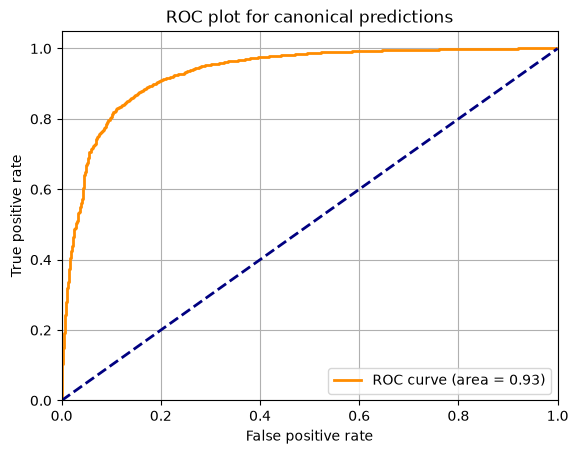

In [19]:
probabilities_list = list(probabilities[ :, 1])
fpr, tpr, thresholds = roc_curve(np.ravel(list(y_test)), np.ravel(probabilities_list))
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr,tpr,color="darkorange",lw=2,label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC plot for canonical predictions")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Predict for all protein and write out the table with learned results

In [20]:
probabilities = clf.predict_proba(learning_values)
proteins['learned_canonical_prob'] = probabilities[ :, 1]
proteins.to_csv('light_and_dark_protein_list_trained.tsv', sep="\t", index=False)